# Trading Algorithm Research

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
prices = yf.download("NVDA", start="2022-01-01")
prices

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2022-01-03,29.992586,30.580071,29.658018,29.687891,391547000
2022-01-04,29.165127,30.338104,28.228139,30.147918,527154000
2022-01-05,27.486311,29.290586,27.415615,28.825576,498064000
2022-01-06,28.057867,28.316759,26.949613,27.522161,454186000
2022-01-07,27.130836,28.300828,26.941646,28.021026,409939000
...,...,...,...,...,...
2026-09-23,225.509995,228.949997,224.020004,228.029999,89547300
2026-09-24,224.580002,224.940002,221.089996,222.080002,77469900


## Generating BUY/SELL signals
* Simple Moving Average (SMA) over a 20 and 50 day window
* Relative Strength Index (RSI) over a 14 days window

In [3]:
# SMA fast/slow
prices["sma_fast"] = prices["Close"].rolling(20).mean()
prices["sma_slow"] = prices["Close"].rolling(50).mean()

# RSI
delta = prices["Close"].diff()
gain = delta.clip(lower=0) # positive changes, 0 otherwise
loss = -delta.clip(upper=0) # negative changes, flipped positive
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
prices["rsi"] = 100 - (100 / (1 + rs))

# Generating BUY/SELL signals based on the data computed above
prices["sma_signal"] = np.where(prices["sma_fast"] > prices["sma_slow"], 1, 0)
prices["signal"] = np.where( # The filtered signal: SMA says buy AND RSI confirms momentum
    (prices["sma_signal"] == 1) & (prices["rsi"] > 50), 1,
    np.where((prices["sma_signal"] == 0) & (prices["rsi"] < 50), 0, np.nan)
)
prices["signal"] = prices["signal"].ffill()
prices["trade"] = prices["signal"].diff()

prices

Price,Close,High,Low,Open,Volume,sma_fast,sma_slow,rsi,sma_signal,signal,trade
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,
Date,,,,,,,,,,,
2022-01-03,29.992586,30.580071,29.658018,29.687891,391547000,NaN,NaN,NaN,0,NaN,NaN
2022-01-04,29.165127,30.338104,28.228139,30.147918,527154000,NaN,NaN,NaN,0,NaN,NaN
2022-01-05,27.486311,29.290586,27.415615,28.825576,498064000,NaN,NaN,NaN,0,NaN,NaN
2022-01-06,28.057867,28.316759,26.949613,27.522161,454186000,NaN,NaN,NaN,0,NaN,NaN
2022-01-07,27.130836,28.300828,26.941646,28.021026,409939000,NaN,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-23,225.509995,228.949997,224.020004,228.029999,89547300,221.029596,215.190378,51.457006,1,1.0,0.0
2026-09-24,224.580002,224.940002,221.089996,222.080002,77469900,221.787313,215.436729,45.821244,1,1.0,0.0


In [4]:
prices.describe()

Price,Close,High,Low,Open,Volume,sma_fast,sma_slow,rsi,sma_signal,signal,trade
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,
count,1189.000000,1189.000000,1189.000000,1189.000000,1.189000e+03,1170.000000,1140.000000,1175.000000,1189.000000,1175.000000,1174.000000
mean,98.069937,99.676884,96.371746,98.108788,3.647144e+08,97.628542,96.999432,54.931831,0.602187,0.593191,0.000852
std,69.773684,70.763779,68.820144,69.875682,1.933891e+08,68.930392,67.648546,16.314939,0.489652,0.491448,0.140025
min,11.186728,11.692904,10.774211,10.931645,6.091276e+07,12.173126,12.965808,8.188127,0.000000,0.000000,-1.000000
25%,26.795973,27.160816,26.281609,26.740154,1.901948e+08,25.761867,25.734904,42.569424,0.000000,0.000000,0.000000
50%,94.072762,95.128752,91.338559,93.332870,3.558810e+08,95.250430,100.303775,54.331051,1.000000,1.000000,0.000000
75%,170.282410,171.329835,166.940596,169.612310,4.889840e+08,168.671612,159.913876,66.849572,1.000000,1.000000,0.000000
max,235.202393,236.000556,229.373344,232.849448,1.543911e+09,222.615551,216.823243,98.629053,1.000000,1.000000,1.000000


In [5]:
buys = prices[prices["trade"] == 1]
sells = prices[prices["trade"] == -1]

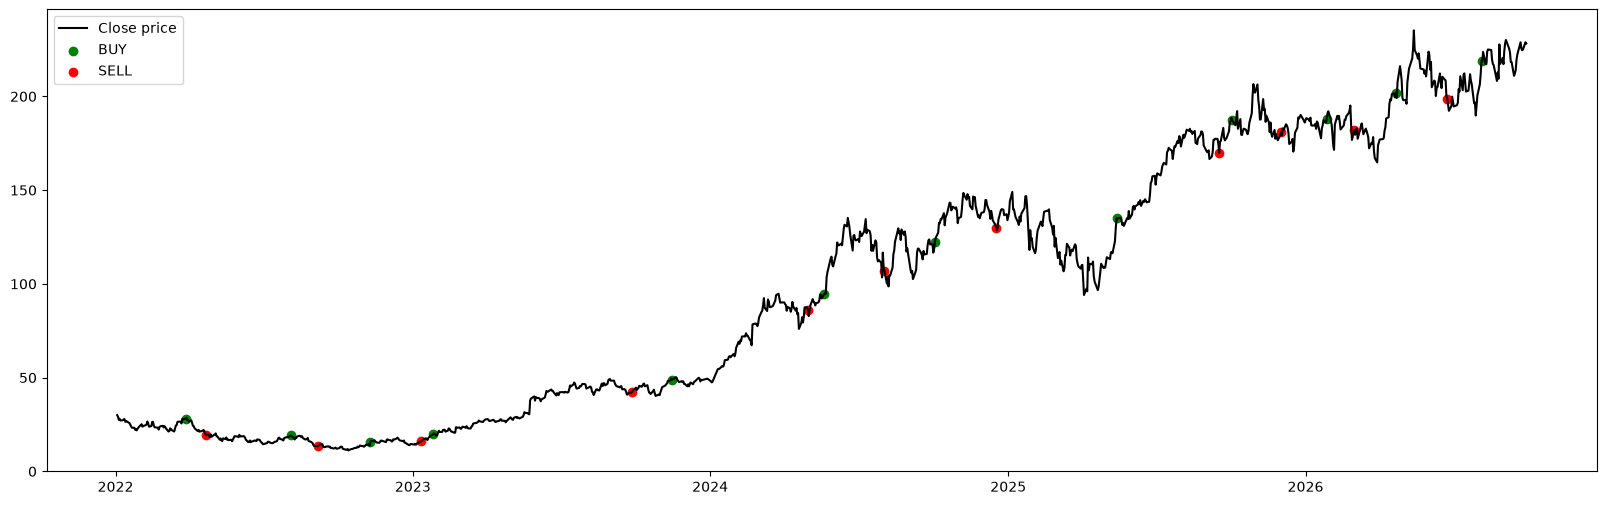

In [9]:
plt.figure(figsize=(20, 6))
plt.plot(prices.index, prices["Close"], label="Close price", color="black")
#plt.plot(prices.index, prices["sma_fast"], label="sma fast", color="orange")
#plt.plot(prices.index, prices["sma_slow"], label="sma slow", color="blue")
plt.scatter(buys.index, buys["Close"], label="BUY", color="green")
plt.scatter(sells.index, sells["Close"], label="SELL", color="red")
plt.legend()
plt.show()